# Optimizing the Piezo Position

``` Pseudo
1. Get scanners current position
2. Set resolution (we know range will be 1 um in the xy plane)
3. Build the sequence, centered around the current position
4. For each position in sequence, go to that position and take an image
5. Calculate the total brightness for each image, and fit a gaussian distribution to the sequence
6. Plot
```

### Scanner Architecture: GUI to Hardware

- **For positioning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_ao** → Hardware
- **For scanning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_finite_sampling_io** → Hardware
- Interfuse selects appropriate hardware
Piezo stages: x, y, z axes
    - ao0 → x-axis
    - ao1 → y-axis  
    - ao2 → z-axis

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

## SPAD Configuration

In [54]:
spad = camera_SPC3
spad._NFrames = 1 
spad._apply_camera_settings()

## Building the Sequence

### Optimization Params
- resolution_x = 3 # pixels
- resolution_y = 3 # pixels
- scan_range = 1e-6 # units are in m; 1 micron for both x and y scans through 2x2 pixel space

In [55]:
resolution_x = 10 # pixels
resolution_y = 10 # pixels
scan_range = 5.0e-6 # meters

piezo = scanning_probe_logic
x_l_bound, x_u_bound = piezo.scanner_constraints.axes['x'].position.bounds
y_l_bound, y_u_bound = piezo.scanner_constraints.axes['y'].position.bounds

# Build sequence
curr_pos = piezo.scanner_position
curr_pos = {k: float(v) for k, v in curr_pos.items()}
start_x = curr_pos['x'] - scan_range / 2
start_y = curr_pos['y'] - scan_range / 2
sequence_x = np.linspace(start_x, start_x + scan_range, int(resolution_x))
sequence_y = np.linspace(start_y, start_y + scan_range, int(resolution_y))

if sequence_x[0] < x_l_bound or sequence_x[-1] > x_u_bound:
    raise ValueError(f"X scan range [{sequence_x[0]:.2e}, {sequence_x[-1]:.2e}] m exceeds scanner bounds [{x_l_bound:.2e}, {x_u_bound:.2e}] m")

if sequence_y[0] < y_l_bound or sequence_y[-1] > y_u_bound:
    raise ValueError(f"Y scan range [{sequence_y[0]:.2e}, {sequence_y[-1]:.2e}] m exceeds scanner bounds [{y_l_bound:.2e}, {y_u_bound:.2e}] m")

print(curr_pos)

{'x': 0.000175093, 'y': 3.12799e-05, 'z': 0.0001018735}


## Sampling Images

### Position Dictionary
```
{'x': 0.0001729267, 'y': 2.8033e-05, 'z': 0.0001018735}
```

In [56]:
pos_dict = {k: float(v) for k, v in curr_pos.items()}
img_samples = []  # Use list instead

for y_pos, y_sample in enumerate(sequence_y):
    for x_pos, x_sample in enumerate(sequence_x):
        pos_dict['x'] = float(x_sample)
        pos_dict['y'] = float(y_sample)
        
        position = piezo.set_target_position(pos_dict, move_blocking=True)
        
        frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
        
        img_samples.append(frame)  # Append to list
        print(f"Captured frame {len(img_samples)}/{resolution_x * resolution_y}")

# Convert to array after collecting all frames
img_samples = np.array(img_samples)
print(f"Final shape: {img_samples.shape}")

Captured frame 1/100
Captured frame 2/100
Captured frame 3/100
Captured frame 4/100
Captured frame 5/100
Captured frame 6/100
Captured frame 7/100
Captured frame 8/100
Captured frame 9/100
Captured frame 10/100
Captured frame 11/100
Captured frame 12/100
Captured frame 13/100
Captured frame 14/100
Captured frame 15/100
Captured frame 16/100
Captured frame 17/100
Captured frame 18/100
Captured frame 19/100
Captured frame 20/100
Captured frame 21/100
Captured frame 22/100
Captured frame 23/100
Captured frame 24/100
Captured frame 25/100
Captured frame 26/100
Captured frame 27/100
Captured frame 28/100
Captured frame 29/100
Captured frame 30/100
Captured frame 31/100
Captured frame 32/100
Captured frame 33/100
Captured frame 34/100
Captured frame 35/100
Captured frame 36/100
Captured frame 37/100
Captured frame 38/100
Captured frame 39/100
Captured frame 40/100
Captured frame 41/100
Captured frame 42/100
Captured frame 43/100
Captured frame 44/100
Captured frame 45/100
Captured frame 46/1

## Calculating the Brightness and Fitting Gaussian

In [57]:
img_samples = np.nan_to_num(img_samples, 0)
brightness_samples = np.sum(img_samples, axis=(1,2))
brightness_samples = brightness_samples.reshape((int(resolution_x), int(resolution_y)))

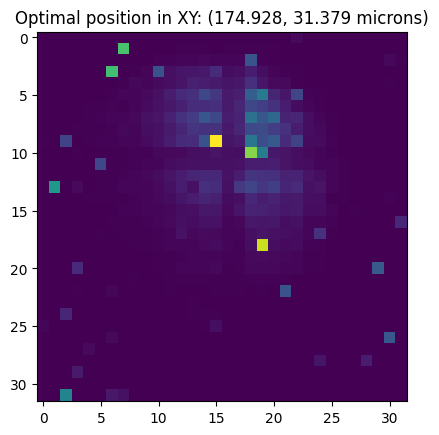

In [ ]:
def gaussian_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, offset):
    x, y = xy
    g = offset + amplitude * np.exp(
        -(((x - xo) ** 2) / (2 * sigma_x ** 2) + ((y - yo) ** 2) / (2 * sigma_y ** 2))
    )

    # add distance from center penalty
    return g.ravel()

X, Y = np.meshgrid(sequence_x, sequence_y)

initial_guess = (
    np.max(brightness_samples),  # amplitude
    curr_pos['x'],  # xo (center x)
    curr_pos['y'],  # yo (center y)
    scan_range / 4,  # sigma_x
    scan_range / 4,  # sigma_y
    np.min(brightness_samples)  # offset
)

position_opt, _ = curve_fit(
    gaussian_2d, 
    (X.ravel(), Y.ravel()), 
    brightness_samples.ravel(), 
    p0=initial_guess
)

amplitude, xo, yo, sigma_x, sigma_y, offset = position_opt

fit = gaussian_2d((X, Y), *position_opt).reshape(resolution_x, resolution_y)

pos_dict['x'], pos_dict['y'] = xo, yo
position = piezo.set_target_position(pos_dict, move_blocking=True)
frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
frame = np.flipud(frame)
plt.title(f"Optimal position in XY: ({xo*10**6:.3f}, {yo*10**6:.3f} microns)")
plt.imshow(frame)

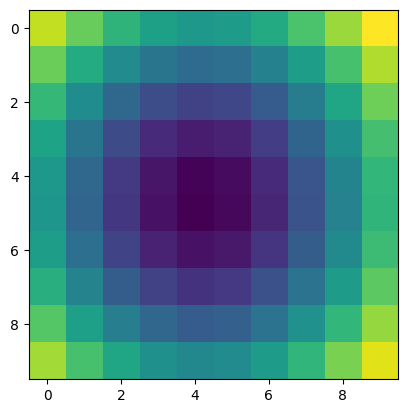

In [59]:
plt.imshow(fit)

## Plot Image